# fastforest

> Fast approximate-forest regression and multiclass classification in Rust, with Python bindings

Fast approximate-forest regression and multiclass classification in Rust, with Python bindings. It can quickly and accurately fit datasets with arbitrarily large row counts (millions of rows or more), and scales down to tiny datasets too.

Across nineteen numeric and mixed-data benchmarks spanning 1,030 to 20,216,100 rows and covering regression, binary classification, and multiclass classification, `FastForest` is always either the fastest to train and predict, or the most accurate. For more results, see the [benchmarks](#benchmarking) section.

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from fastforest import FastForest,FastForestClassifier,feature_dependence,feature_relations

In [2]:
#| hide
from pathlib import Path
from IPython.display import HTML
from fastforest.tools import CLASSIFICATION,REGRESSION,DatasetView,load_datasets,load_results,mk_table

In [3]:
#| hide
results = Path("../tools/results")
datasets = load_datasets(results/"datasets.csv")
regression = load_results(results/"regression.csv", datasets)
classification = load_results(results/"classification.csv", datasets)

### Regression

In [4]:
#| echo: false
HTML(mk_table(regression, [DatasetView("sgemm"), DatasetView("rossmann")], REGRESSION, "summary"))

HTML(<table>
  <thead>
    <tr>
      <th>Dataset</th>
      <th>Model</th>
      <th align="right">RMSE ↓</th>
      <th align="right">R² ↑</th>
      <th align="right">Fit (s) ↓</th>
      <th align="right">Predict (s) ↓</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="5"><strong><a href="https://archive.ics.uci.edu/dataset/440/sgemm+gpu+kernel+performance">SGEMM GPU</a></strong><br><sub>241,600 rows · 14 features · numeric</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.06</td>
      <td align="right"><strong>1.00</strong></td>
      <td align="right"><strong>0.08</strong></td>
      <td align="right">0.016</td>
    </tr>
    <tr>
      <td>AutoForest</td>
      <td align="right">0.04</td>
      <td align="right"><strong>1.00</strong></td>
      <td align="right">0.31</td>
      <td align="right"><strong>0.014</strong></td>
    </tr>
    <tr>
      <td>autogrow</td>
      <td align="right">0.04</td>
      <td align="right"><strong>1.00</strong></td>
      <td align="right">0.81</td>
      <td align="right">0.045</td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right"><strong>0.03</strong></td>
      <td align="right"><strong>1.00</strong></td>
      <td align="right">1.86</td>
      <td align="right">0.136</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right">0.20</td>
      <td align="right">0.97</td>
      <td align="right">1.23</td>
      <td align="right">0.022</td>
    </tr>
    <tr>
      <td rowspan="5"><strong><a href="https://www.kaggle.com/competitions/rossmann-store-sales">Rossmann Store Sales</a></strong><br><sub>844,338 rows · 16 features · mixed</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.15</td>
      <td align="right">0.87</td>
      <td align="right"><strong>0.42</strong></td>
      <td align="right"><strong>0.028</strong></td>
    </tr>
    <tr>
      <td>AutoForest</td>
      <td align="right">0.13</td>
      <td align="right"><strong>0.91</strong></td>
      <td align="right">3.00</td>
      <td align="right">0.033</td>
    </tr>
    <tr>
      <td>autogrow</td>
      <td align="right"><strong>0.12</strong></td>
      <td align="right"><strong>0.91</strong></td>
      <td align="right">7.37</td>
      <td align="right">0.065</td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">0.26</td>
      <td align="right">0.61</td>
      <td align="right">20.18</td>
      <td align="right">0.078</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right">0.30</td>
      <td align="right">0.46</td>
      <td align="right">2.87</td>
      <td align="right">0.051</td>
    </tr>
  </tbody>
</table>)

<sub>Bold is best for that dataset and metric. AutoForest includes automatic sample sizing; autogrow additionally sizes the forest. FastForest rows were measured on an Apple M5 Max; the other rows on an Apple M4 Pro; fit includes preprocessing.</sub>

The SGEMM target is the log-transformed mean runtime.

### Classification

In [5]:
#| echo: false
HTML(mk_table(classification, [DatasetView("covertype_bin"), DatasetView("adult")], CLASSIFICATION, "summary"))

HTML(<table>
  <thead>
    <tr>
      <th>Dataset</th>
      <th>Model</th>
      <th align="right">F1 acc ↑</th>
      <th align="right">Log loss ↓</th>
      <th align="right">Fit (s) ↓</th>
      <th align="right">Proba (s) ↓</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="3"><strong><a href="https://archive.ics.uci.edu/dataset/31/covertype">Covertype</a></strong><br><sub>581,012 rows · binary features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right"><strong>0.93</strong></td>
      <td align="right"><strong>0.15</strong></td>
      <td align="right"><strong>0.70</strong></td>
      <td align="right"><strong>0.062</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">0.92</td>
      <td align="right">0.17</td>
      <td align="right">4.33</td>
      <td align="right">0.210</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right">0.74</td>
      <td align="right">0.57</td>
      <td align="right">2.38</td>
      <td align="right">0.076</td>
    </tr>
    <tr>
      <td rowspan="3"><strong><a href="https://www.openml.org/d/1590">Adult Census Income</a></strong><br><sub>48,842 rows · 14 features · mixed</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.81</td>
      <td align="right">0.31</td>
      <td align="right"><strong>0.08</strong></td>
      <td align="right"><strong>0.009</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">0.80</td>
      <td align="right">0.37</td>
      <td align="right">0.96</td>
      <td align="right">0.026</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right"><strong>0.82</strong></td>
      <td align="right"><strong>0.27</strong></td>
      <td align="right">1.42</td>
      <td align="right">0.027</td>
    </tr>
  </tbody>
</table>)

F1 acc is macro-averaged F1, giving every class equal weight. Covertype is passed with its supplied binary features; FastForest bundles exclusive indicators automatically.

## Install

```bash
pip install fastforest
```

This installs the Python library and the native `fastforest-fit`, `fastforest-predict`, `fastforest-convert`, and `fastforest-compile` executables.

## Training and Validation

In [6]:
rng = np.random.default_rng(42)
X = rng.random((1_000, 6))
y = 4*X[:, 0] - 2*X[:, 1] + X[:, 5]

ff = FastForest(seed=42, oob=True).fit(X, y)
preds = ff.predict(X[:5])
preds

array([3.0069957, 2.3236141, 1.0881499, 2.9502003, 3.3705614],
      dtype=float32)

In [7]:
labels = np.where(X[:, 0]+X[:, 1] > 1, "high", "low")
ffc = FastForestClassifier(seed=42, oob=True).fit(X, labels)
probs,classes = ffc.predict_proba(X[:5]), ffc.predict(X[:5])
classes

array(['high', 'high', 'high', 'high', 'low'], dtype='<U4')

`X` may contain numeric values, numeric strings, ordinary strings, and configured missing values. Regression `y` is converted to contiguous `float32` and must be finite. Classification labels may be numeric or strings; `classes_` records their probability-column order. Missing labels and single-class targets are rejected.

### Automatic sizing

`AutoForest` and `AutoForestClassifier` size the samples while retaining the ordinary estimator API; `autogrow=True` also sizes the forest:

In [8]:
from fastforest.auto import AutoForest,AutoForestClassifier

In [9]:
model = AutoForest(seed=42).fit(X, y)
classifier = AutoForestClassifier(seed=42).fit(X, labels)
grown = AutoForest(autogrow=True, seed=42).fit(X, y)

For sufficiently large data, one parallel eight-tree screen tries only larger `bootstrap_max` and `max_node_samples` values. Each extra level requires another 1% reduction in OOB loss, independently on each axis. Ordinary sizing tries bootstrap limits of 80k, 120k, 160k, and 200k and node samples of 640, 960, and 1280; autogrow widens these to 80k, 160k, 240k, and 320k and 640, 1280, and 1920. When the row cap removes wider bootstrap choices, their vacant comparison slots are filled from the ordinary grid. The screen is skipped unless rows exceed `2 * bootstrap_max * max(1, classes-1)`, so the default thresholds are 80,000 rows for regression and binary classification, 160,000 for three classes, and 480,000 for seven classes.

By default, the final model uses fastforest's ordinary adaptive 32–64 tree rule and does not enable OOB. With `autogrow=True`, it instead grows in 32-tree batches. An independent random set of at most 40,000 tracking rows per output is fixed before the first batch; at every checkpoint, each row uses only trees for which it was out-of-bag. Another batch is added while cumulative regression MSE or classification Brier loss improves by at least 1%; the first batch that fails this test is discarded by default. Growth is capped at 512 trees by default; `keep_last_batch`, `min_improvement`, `tree_batch_size`, and `max_trees` control these choices.

## Creating and Using Models

Models can be saved as compact, portable `.ffm` files containing the forest, fitted preprocessing schema, task, and class labels. A loaded model supports ordinary in-memory prediction as well as bounded file prediction:

```python
from fastforest import load

model.save("model.ffm")
restored = load("model.ffm")
predictions = restored.predict(X)
restored.predict_file("test.csv", "predictions.csv")
restored.save_executable("model-predict")
```

`predict_file` processes CSV or Arrow IPC/Feather in bounded batches rather than loading the whole input. `save_executable` builds a standalone predictor for the current platform, embedding both the model and Rust prediction runtime; building it requires a Rust toolchain, but running it requires neither Python nor a separate model file.

Installing fastforest also provides four commands. Their parsing, preprocessing, fitting, persistence, and prediction run in Rust:

```console
fastforest-fit train.csv --target price --task regression --output model.ffm
fastforest-predict model.ffm test.csv --output predictions.csv
fastforest-convert numeric.csv --output numeric.arrow
fastforest-compile model.ffm --output model-predict
./model-predict test.csv --output predictions.csv
```

`fastforest-fit` accepts mixed CSV or numeric Arrow input and supports `regression` and `classification`; classification prediction accepts `--proba`. `fastforest-convert` streams numeric CSV into standard Arrow IPC for faster repeated ingestion. Run any command with `--help` for its complete estimator, schema, and batching options.

The native `fastforest-predict` binary, using a default model trained on an 80% Concrete Strength split, predicts from Arrow end-to-end in **4.5 ms** for one row and **4.9 ms** for all 206 validation rows. Reproduce it with `python tools/cli_bench.py`.

## Benchmarking

This section contains additional results; all benchmarks, including those at the top of the README, follow the approaches described here. Unless noted otherwise, results use one reproducible 80/20 split, stratified for classification. Fit timing includes model construction, schema inspection, preprocessing, and fitting, but excludes process startup and inter-process transfer. Prediction timing includes input transformation. Every model/dataset combination has a 180-second limit.

Each `AutoForest` row uses the ordinary adaptive tree count. Its following `autogrow` row uses the same sample sizer with growth capped at 192 trees. Both include the sizing screen and final fit in fit time, and appear only when training rows exceed the sample-sizer activation threshold.

### Regression

In [10]:
#| echo: false
HTML(mk_table(regression,
    [DatasetView(name) for name in ("california", "concrete", "diamonds", "allstate", "diabetes", "bluebook", "walmart", "ashrae")], REGRESSION))

HTML(<table>
  <thead>
    <tr>
      <th>Dataset</th>
      <th>Model</th>
      <th align="right">RMSE ↓</th>
      <th align="right">R² ↑</th>
      <th align="right">Fit (s) ↓</th>
      <th align="right">Predict (s) ↓</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="3"><strong><a href="https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset">California Housing</a></strong><br><sub>20,640 rows · 8 features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.50</td>
      <td align="right">0.81</td>
      <td align="right"><strong>0.09</strong></td>
      <td align="right"><strong>0.003</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">0.51</td>
      <td align="right">0.80</td>
      <td align="right">0.44</td>
      <td align="right">0.013</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right"><strong>0.47</strong></td>
      <td align="right"><strong>0.83</strong></td>
      <td align="right">0.96</td>
      <td align="right">0.006</td>
    </tr>
    <tr>
      <td rowspan="3"><strong><a href="https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength">Concrete Strength</a></strong><br><sub>1,030 rows · 8 features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">5.70</td>
      <td align="right">0.87</td>
      <td align="right"><strong>0.01</strong></td>
      <td align="right"><strong>0.000</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">5.46</td>
      <td align="right">0.88</td>
      <td align="right">0.06</td>
      <td align="right">0.013</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right"><strong>4.65</strong></td>
      <td align="right"><strong>0.92</strong></td>
      <td align="right">0.78</td>
      <td align="right">0.005</td>
    </tr>
    <tr>
      <td rowspan="3"><strong><a href="https://www.openml.org/d/42225">Diamonds</a></strong><br><sub>53,940 rows · 9 features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">545</td>
      <td align="right"><strong>0.98</strong></td>
      <td align="right"><strong>0.11</strong></td>
      <td align="right"><strong>0.009</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">550</td>
      <td align="right"><strong>0.98</strong></td>
      <td align="right">0.97</td>
      <td align="right">0.032</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right"><strong>541</strong></td>
      <td align="right"><strong>0.98</strong></td>
      <td align="right">1.27</td>
      <td align="right">0.018</td>
    </tr>
    <tr>
      <td rowspan="5"><strong><a href="https://www.openml.org/d/42571">Allstate Claims</a></strong><br><sub>188,318 rows · 130 features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">1,924</td>
      <td align="right">0.55</td>
      <td align="right"><strong>0.81</strong></td>
      <td align="right"><strong>0.046</strong></td>
    </tr>
    <tr>
      <td>AutoForest</td>
      <td align="right">1,922</td>
      <td align="right">0.55</td>
      <td align="right">2.66</td>
      <td align="right">0.053</td>
    </tr>
    <tr>
      <td>autogrow</td>
      <td align="right">1,911</td>
      <td align="right">0.55</td>
      <td align="right">4.24</td>
      <td align="right">0.060</td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td colspan="4" align="center">timed out at 180s with 50 trees</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right"><strong>1,861</strong></td>
      <td align="right"><strong>0.58</strong></td>
      <td align="right">4.29</td>
      <td align="right">0.362</td>
    </tr>
    <tr>
      <td rowspan="5"><strong><a href="https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008">Diabetes 130-US Hospitals</a></strong><br><sub>101,766 rows 

For mixed data, the sklearn benchmarks use a custom pipeline based on [scikit-learn's official preprocessing guidance and examples](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html): wholly numeric columns are parsed and median-imputed, categorical columns use one-hot encoding through 20 levels and target encoding above that, and HistGBM uses native categoricals through its 255-level limit. This numeric parsing is needed for sensible handling of raw CSV-like tables; otherwise the pipeline uses the documented sklearn behavior. fastforest requires no custom preprocessing and takes the original datasets directly. sklearn RF timed out on a smaller Allstate run, so its default configuration was not run. For validation, Blue Book uses its final 12,000 rows, Walmart uses a 12-week chronological holdout to match the competition's future-period forecasting setup, Rossmann uses its final six weeks, and ASHRAE uses December 2016.

### Classification

In [11]:
#| echo: false
HTML(mk_table(classification,
    [DatasetView(name) for name in ("bank", "click", "shuttle", "airlines", "higgs", "sf_police", "kddcup99")], CLASSIFICATION))

HTML(<table>
  <thead>
    <tr>
      <th>Dataset</th>
      <th>Model</th>
      <th align="right">F1 acc ↑</th>
      <th align="right">Log loss ↓</th>
      <th align="right">Fit (s) ↓</th>
      <th align="right">Proba (s) ↓</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="3"><strong><a href="https://www.openml.org/d/1461">Bank Marketing</a></strong><br><sub>45,211 rows · 16 mixed features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.75</td>
      <td align="right"><strong>0.20</strong></td>
      <td align="right"><strong>0.07</strong></td>
      <td align="right"><strong>0.007</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">0.72</td>
      <td align="right">0.23</td>
      <td align="right">0.29</td>
      <td align="right">0.025</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right"><strong>0.76</strong></td>
      <td align="right"><strong>0.20</strong></td>
      <td align="right">1.37</td>
      <td align="right">0.026</td>
    </tr>
    <tr>
      <td rowspan="3"><strong><a href="https://www.openml.org/d/42733">Click Prediction Small</a></strong><br><sub>39,948 rows · 11 mixed features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right"><strong>0.54</strong></td>
      <td align="right">0.44</td>
      <td align="right"><strong>0.17</strong></td>
      <td align="right"><strong>0.010</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right"><strong>0.54</strong></td>
      <td align="right">0.44</td>
      <td align="right">0.47</td>
      <td align="right">0.027</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right">0.52</td>
      <td align="right"><strong>0.41</strong></td>
      <td align="right">0.72</td>
      <td align="right">0.017</td>
    </tr>
    <tr>
      <td rowspan="3"><strong><a href="https://www.openml.org/d/40685">Statlog Shuttle</a></strong><br><sub>58,000 rows · 9 numeric features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.76</td>
      <td align="right"><strong>0.00</strong></td>
      <td align="right"><strong>0.02</strong></td>
      <td align="right"><strong>0.002</strong></td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right"><strong>0.85</strong></td>
      <td align="right"><strong>0.00</strong></td>
      <td align="right">0.21</td>
      <td align="right">0.014</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right">0.58</td>
      <td align="right">0.24</td>
      <td align="right">0.71</td>
      <td align="right">0.012</td>
    </tr>
    <tr>
      <td rowspan="5"><strong><a href="https://www.openml.org/d/41672">Airlines Delay</a></strong><br><sub>539,383 rows · 7 mixed features</sub></td>
      <td><strong>fastforest</strong></td>
      <td align="right">0.65</td>
      <td align="right"><strong>0.61</strong></td>
      <td align="right"><strong>0.32</strong></td>
      <td align="right"><strong>0.084</strong></td>
    </tr>
    <tr>
      <td>AutoForest</td>
      <td align="right">0.65</td>
      <td align="right"><strong>0.61</strong></td>
      <td align="right">1.54</td>
      <td align="right">0.097</td>
    </tr>
    <tr>
      <td>autogrow</td>
      <td align="right"><strong>0.66</strong></td>
      <td align="right"><strong>0.61</strong></td>
      <td align="right">2.45</td>
      <td align="right">0.117</td>
    </tr>
    <tr>
      <td>sklearn RF</td>
      <td align="right">0.63</td>
      <td align="right">0.70</td>
      <td align="right">139.53</td>
      <td align="right">0.409</td>
    </tr>
    <tr>
      <td>sklearn HistGBM</td>
      <td align="right">0.64</td>
      <td align="right">0.62</td>
      <td align="right">2.18</td>
      <td align="right">0.095</td>
    </tr>
    <tr>
      <td rowspan="5"><strong><a href="https://www.openml.org/d/42769">HIGGS</a></strong><br><sub>1,000,000 rows · 28 numeri

### Reproducing the benchmarks

Install the development dependencies and release build, then reproduce one dataset with:

```bash
pip install -e '.[dev]'
cargo build --release --bins
python tools/stage_binaries.py
maturin develop --release
python tools/accuracy.py --dataset california
```

Available regression datasets are `sgemm`, `california`, `concrete`, `diamonds`, `allstate`, `diabetes`, `bluebook`, `bluebook_raw`, `walmart`, `walmart_raw`, and `walmart_nodate`. Classification choices are `covertype`, `adult`, `bank`, `click`, `shuttle`, `airlines`, `higgs`, `sf_police`, and `kddcup99`. Run one forest alone with `--ff_only`, `--auto_only`, or `--rf_only`, or reproduce all displayed results with:

```bash
for dataset in sgemm california concrete diamonds allstate diabetes; do
  python tools/accuracy.py --dataset "$dataset"
done

for dataset in covertype adult bank click shuttle airlines higgs sf_police kddcup99; do
  python tools/accuracy.py --dataset "$dataset"
done

python tools/accuracy.py --dataset walmart --ff_only
```

## Data preparation

FastForest fits a deterministic schema for every input column:

1. Non-missing values are parsed as `float32` when every value can be parsed and are otherwise treated as strings. Numeric columns sort numerically and other columns sort lexically. Numeric columns whose values are all integral retain that metadata so analysis displays them with no decimal places.
2. A constant column is discarded. Every other column becomes one zero-based rank in its sort order; binary columns are therefore ordinary boolean features.
3. The default missing value is the empty value. Override it per column with `missing_values`, using column names or indexes. Missing is encoded as a separate rank, and each split learns whether it belongs in its left or right child. No imputation or indicator column is added. By default, a column containing no training missing values rejects missing values during prediction; set `allow_new_missing=True` to route them to the larger child seen in the split's sampled rows. Entirely missing columns are discarded.

```python
X = np.array([
    ["18", "red",   ""],
    ["42", "blue",  "3.5"],
    ["31", "green", "2.0"],
], dtype=object)

model = FastForest(missing_values={2: ""}).fit(X, [1, 4, 3])
```

Binary columns with no missing values are checked for mutual exclusivity on at most 10,000 sampled training-pool rows. Compatible indicators are collapsed into one categorical feature when their bundle is active in more than half the sample. The fitted membership and order are saved with the model; importance, explanations, and partial dependence treat the bundle as one feature and `column_info_` lists its members.

Date and time columns are detected by default from at most 200 random training-pool rows using a conservative list of common formats. Every sampled non-missing value must match; ambiguous day/month forms remain candidates until a value above 12 resolves them, with month-first used if they remain ambiguous. Detected formats are saved with the model and never inferred again during prediction. Date columns are expanded natively using the same parts as fastai's `add_datepart`: year, month, ISO week, day, day-of-week, day-of-year, month/quarter/year boundary flags, hour, minute, second, and Unix elapsed seconds. Constant parts are discarded automatically, while missing or unparsable date values produce ordinary missing date parts.

Set `date_columns={}` to disable detection, or provide explicit `strftime` formats to override it:

```python
model = FastForest(date_columns={"saledate":"%m/%d/%Y %H:%M"}).fit(X, y)
```

Ranking is a compact training representation, not a prediction-time requirement for numeric columns. After fitting, rank cutoffs are converted back to native numeric boundaries, so seen and unseen numeric values are compared directly without a rank lookup. Nonnumeric values are mapped through their fitted lexical ordering, with unseen values receiving their insertion rank. Missing numeric values remain `NaN` during native prediction and follow the direction stored in each split.

Python accepts pandas data frames, NumPy arrays, and Arrow tables, selects the bounded training pool first, converts only retained rows, and performs the bounded 200-row date-format check. The native CSV path likewise builds Arrow arrays only for retained rows, while Arrow IPC keeps its existing typed buffers. Full-column schema fitting and inference transformation then run in Rust behind the Arrow boundary, including numeric and lexical interpretation, missing values, categories, date expansion, and parallel column processing. The compact ranked training matrix and native-value prediction matrix remain internal implementation details.

Generated ranks and date parts remain internal. Feature importance, explanations, and partial-dependence results aggregate them back to the original column and display its original values. Fitted interpretations are available in `model.column_info_`.

For reproducible sklearn comparisons on the same raw dataframe, `sklearn_preprocessor` implements the policy used by the benchmark: wholly numeric columns are parsed and median-imputed, categorical columns are one-hot encoded through 20 levels and target encoded above 20, and explicitly supplied missing markers are converted to nulls.

```python
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from fastforest import sklearn_preprocessor

preprocess = sklearn_preprocessor(X_train, missing_values={"age":"?"})
model = make_pipeline(preprocess, RandomForestRegressor(n_jobs=-1))
model.fit(X_train, y_train)
```

Install the optional dependencies with `pip install 'fastforest[sklearn]'`.

## Algorithm

Each regression tree draws `min(floor(bootstrap_fraction * n_rows), bootstrap_max)` training rows. Classification treats `bootstrap_max` as a per-output cap and therefore uses `bootstrap_max * max(1, n_classes-1)` total rows per tree. `replacement=None` adaptively samples with replacement below 10,000 regression rows or 40,000 classification rows, and otherwise without it; pass `True` or `False` to override this. When `bootstrap_fraction=None`, it resolves to 0.8 with OOB enabled and 1 otherwise. Fractions above 1 are supported with replacement; without replacement the maximum is 1. Pass `bootstrap_max=None` to disable the cap. At each node, the default histogram splitter:

1. A node with fewer than `min_node_size` rows, or whose first `max_node_samples` sampled targets are equal, becomes a leaf.
2. A random contiguous window containing at most `max_node_samples` of the node's shuffled rows is selected.
3. The tree randomly selects the configured fraction of encoded features, with a minimum of one.
4. For each selected feature, the sampled rows are sorted by their encoded rank and every distinct observed boundary is evaluated. Regression minimizes size-weighted sample standard deviation, shrinking each child mean toward its parent by a three-row prior. Classification uses tree-frequency-weighted entropy. Missing values occupy the final contiguous rank range: the ordinary pass leaves them right, and a second ordered pass tries them left only when that range is nonempty. These scores penalize poorly supported small children directly; the only hard requirement is that both children are nonempty.
5. Every regression leaf predicts the mean target of all tree-sampled rows that reached it. A classification leaf stores their class-probability vector. Thus leaf fitting processes each tree's capped sample once in total; it does not route the whole dataset through every tree.

By default, forest size targets two million sampled rows across its trees: `n_trees = clamp(ceil(2_000_000 / sampled_rows_per_tree), 32, 64)`. Set `n_trees` to override it. The standard regression cap resolves to 50 trees; Covertype's seven-class cap resolves to 32. Other defaults are minimum node size 8, all rows capped at 40,000 per output, 90% feature sampling for regression or 60% for classification, at most 320 evaluated rows per node, and a three-row regression split prior. Enabling OOB changes the default sampling fraction to 0.8 so every row can receive held-out predictions. Preprocessing and trees build in parallel over columns and trees respectively. Classification prediction divides rows into roughly four blocks per Rayon worker and calculates how many fitted trees fit in a conservative 512 KiB working-set budget, including nodes and leaf probabilities. It processes those cache-sized tree batches within each row block; small trees retain row locality, while large trees automatically become tree-major. Supplying `seed` makes the fitted forest deterministic regardless of parallel scheduling.

`max_features` accepts `"sqrt"` or a fraction in `(0, 1]`; its default is `0.9` for regression and `0.6` for classification.

`FastForestClassifier.predict_proba` averages the leaf probabilities over trees, while `predict` returns the corresponding original label. With OOB enabled, `oob_decision_function_`, `oob_counts_`, and OOB accuracy `oob_score_` are available; `oob_indices_` maps the bounded results to original training rows. Ordinary fitting remains bounded by the shared pool, per-output row cap, and `max_node_samples` rows per node.

## Split selection and tuning

The histogram splitter is the production default. The original random-cutoff search remains available as a simpler teaching implementation:

In [12]:
model = FastForest(random_splitter=True, seed=42).fit(X, y)
fixed = FastForest(max_features="sqrt", seed=42).fit(X, y)

The histogram search randomly selects `max_features`, builds sparse target-statistic histograms from the node evaluation window, and checks every observed boundary for those features. The random splitter instead proposes random `(feature, value)` cutoffs, deduplicates them, and evaluates them on the same kind of node window. Its candidate count is controlled by `cutoff_divisor`; `max_features` is ignored when `random_splitter=True`.

The focused sweep tool takes comma-separated levels for every tree hyperparameter. The first value is the shared baseline and each later value creates one one-axis configuration. It compares an eight-tree batched OOB screen with ordinary resolved-tree fits on the dataset's canonical validation split, recording OOB, validation, and both training losses in one per-dataset CSV:

```bash
python tools/sweep.py --dataset california
```

## Out-of-bag predictions

OOB calculation is opt-in with `oob=True`. After fitting:

- `oob_prediction_` contains each training row's mean prediction from trees that did not sample that row.
- `oob_counts_` contains the number of contributing trees.
- A row with no contributing tree has count zero and prediction `NaN`.
- Sampling without replacement at `bootstrap_fraction=1.0` leaves no OOB rows, so all counts are zero and predictions are `NaN`.

Both attributes are `None` when OOB is disabled.

## Model analysis

FastForest includes analysis tools with ordinary NumPy results. Data frames are accepted and supply feature names automatically; arrays use `x0`, `x1`, and so on. Sampling happens before Arrow conversion: permutation importance and feature relations use at most 5,000 rows, PDP/ICE uses 500, feature dependence uses 5,000, and drop-column importance uses at most 40,000 training and 5,000 validation rows by default. These limits are configurable through each function's sampling arguments. Plot methods import matplotlib only when called.

The executable examples below use the 1,030-row Concrete Compressive Strength dataset, cached under `data/`.

In [13]:
Xc,yc = fetch_openml(data_id=44959, return_X_y=True, as_frame=True, data_home="../data")
Xc_train,Xc_valid,yc_train,yc_valid = train_test_split(Xc, yc, test_size=.2, random_state=42)
concrete = FastForest(seed=42, oob=True).fit(Xc_train, yc_train)

### Importance

Use validation-set permutation importance by default. It measures the drop in model score after shuffling a feature without retraining:

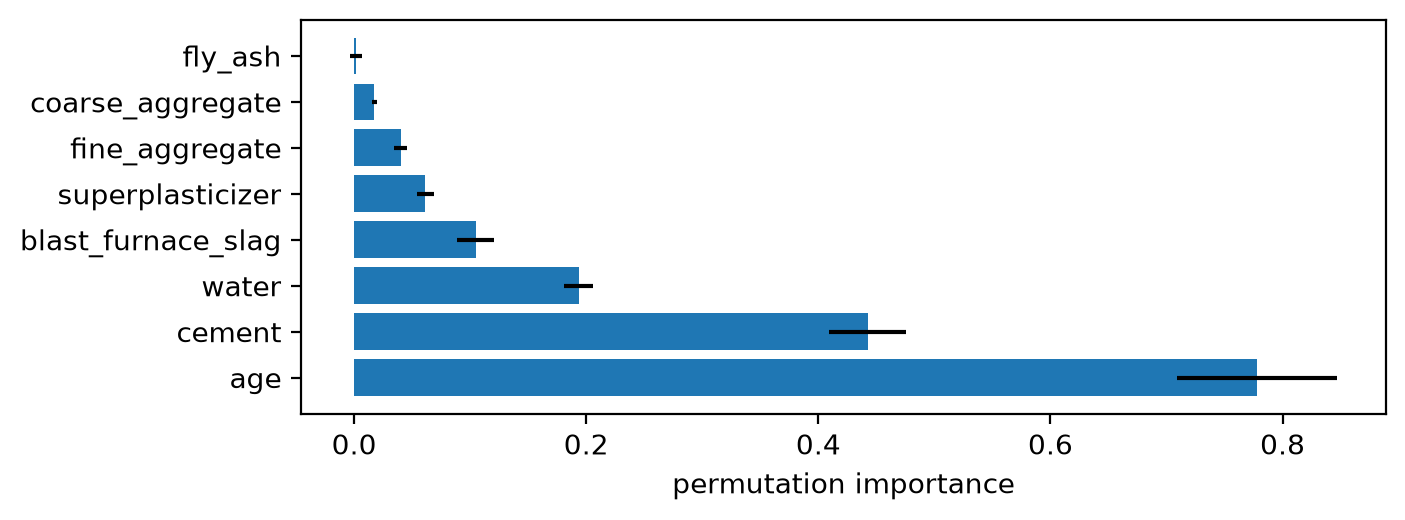

In [14]:
importance = concrete.feature_importance(Xc_valid, yc_valid)
importance.plot();

Correlated features can substitute for one another and therefore look individually unimportant. Permute them together to measure their joint importance:

```python
importance = model.feature_importance(X_valid, y_valid,
    features={"location": ["latitude", "longitude"]})
```

`model.drop_column_importance(X_train, y_train, X_valid, y_valid)` performs the slower complementary analysis: it refits the forest without each feature. It accepts the same `features` groups. `model.split_importance()` returns the nearly free, normalized training-time split-gain measure, but permutation or grouped permutation is preferable because split importance is biased by the available cutoffs and correlated predictors.

### Individual predictions and uncertainty

In [15]:
explanation = concrete.explain(Xc_valid[:3])
explanation.row(0)

[('age', 365, 10.391003608703613),
 ('fine_aggregate', 670.0, 7.147571086883545),
 ('water', 228.0, -3.5705411434173584),
 ('blast_furnace_slag', 114.0, 2.2464847564697266),
 ('superplasticizer', 0.0, -1.9710803031921387),
 ('coarse_aggregate', 932.0, 0.5310124754905701),
 ('cement', 266.0, -0.4772198796272278),
 ('fly_ash', 0.0, 0.08554995059967041)]

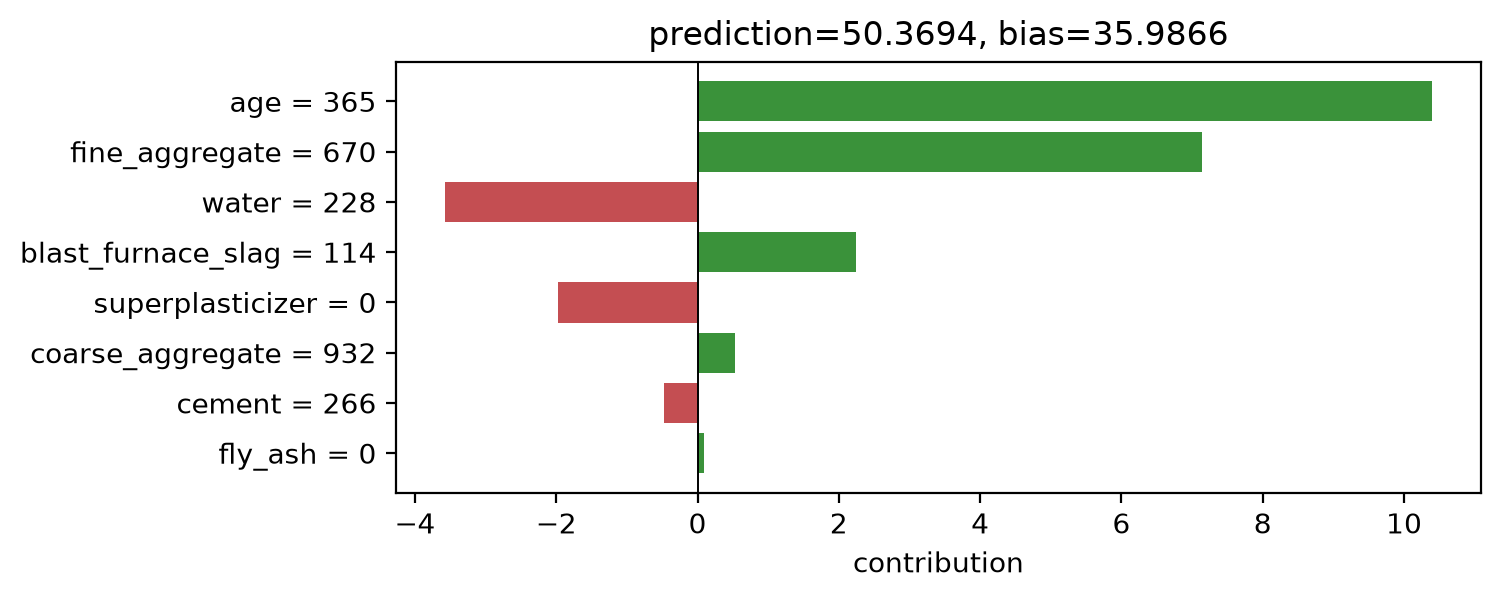

In [16]:
explanation.plot(0);

In [17]:
tree_predictions = concrete.predict_trees(Xc_valid)
prediction_std = concrete.predict_std(Xc_valid)
prediction_std[:5]

array([2.820218 , 9.91288  , 7.603904 , 5.795989 , 5.0215983],
      dtype=float32)

For every row, `prediction = bias + contributions.sum()`. Contributions telescope through each tree's decision path and are then averaged across trees. They explain this forest's computation, not causality; correlated features can redistribute contributions between themselves.

### Partial dependence and ICE

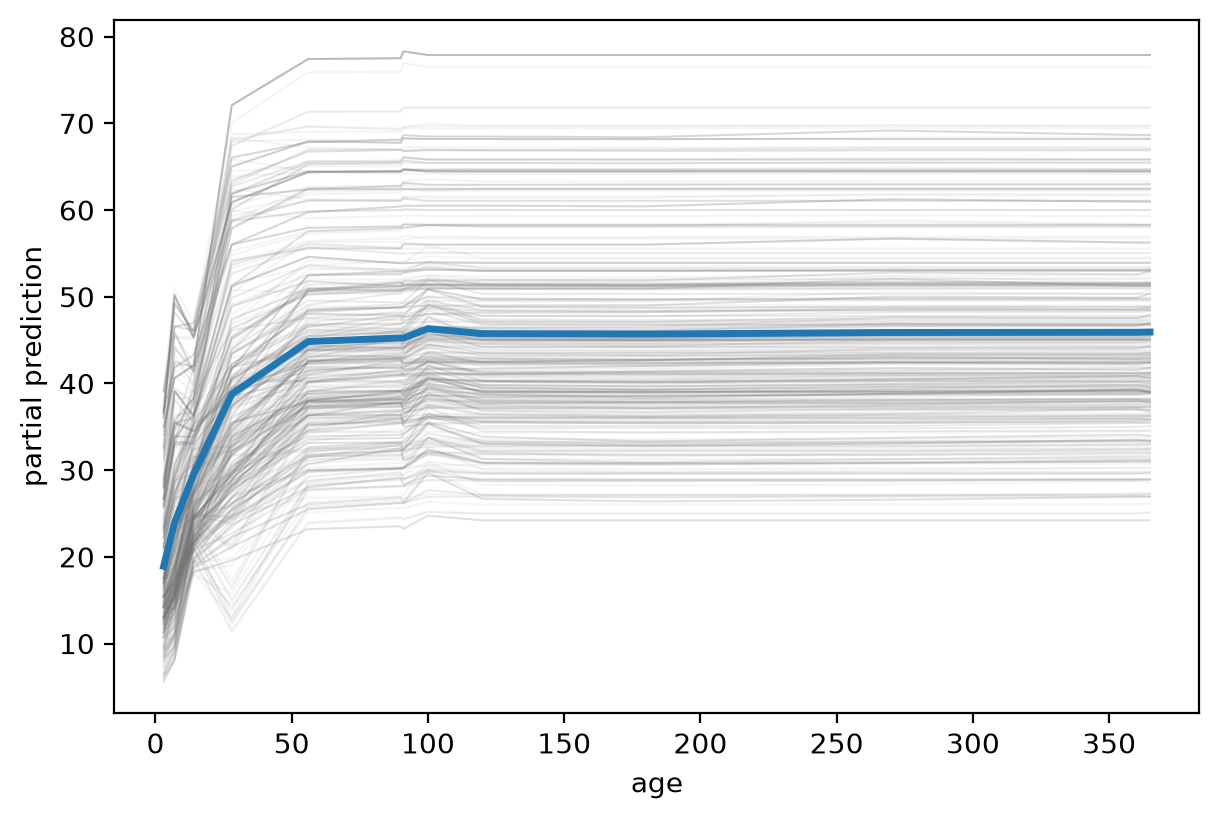

In [18]:
age = concrete.partial_dependence(Xc_train, "age")
age.plot();

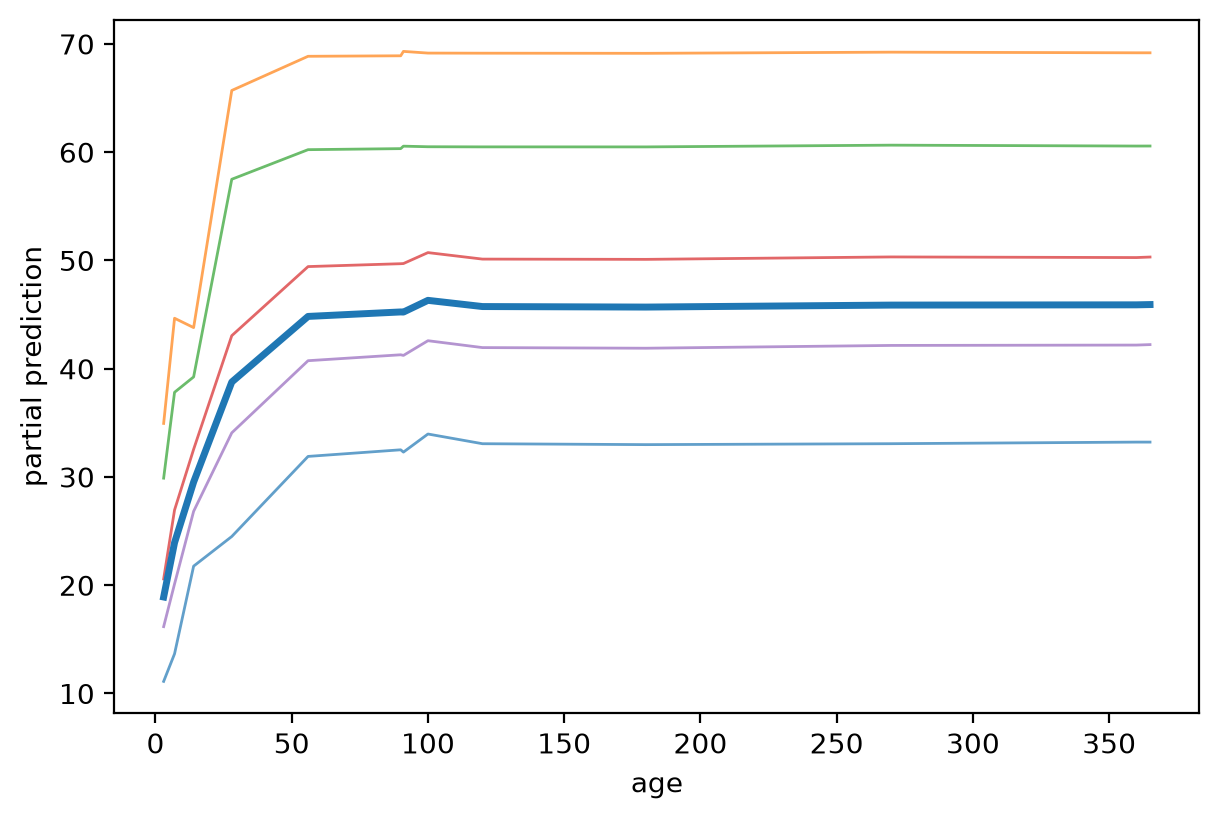

In [19]:
age.plot(clusters=5);

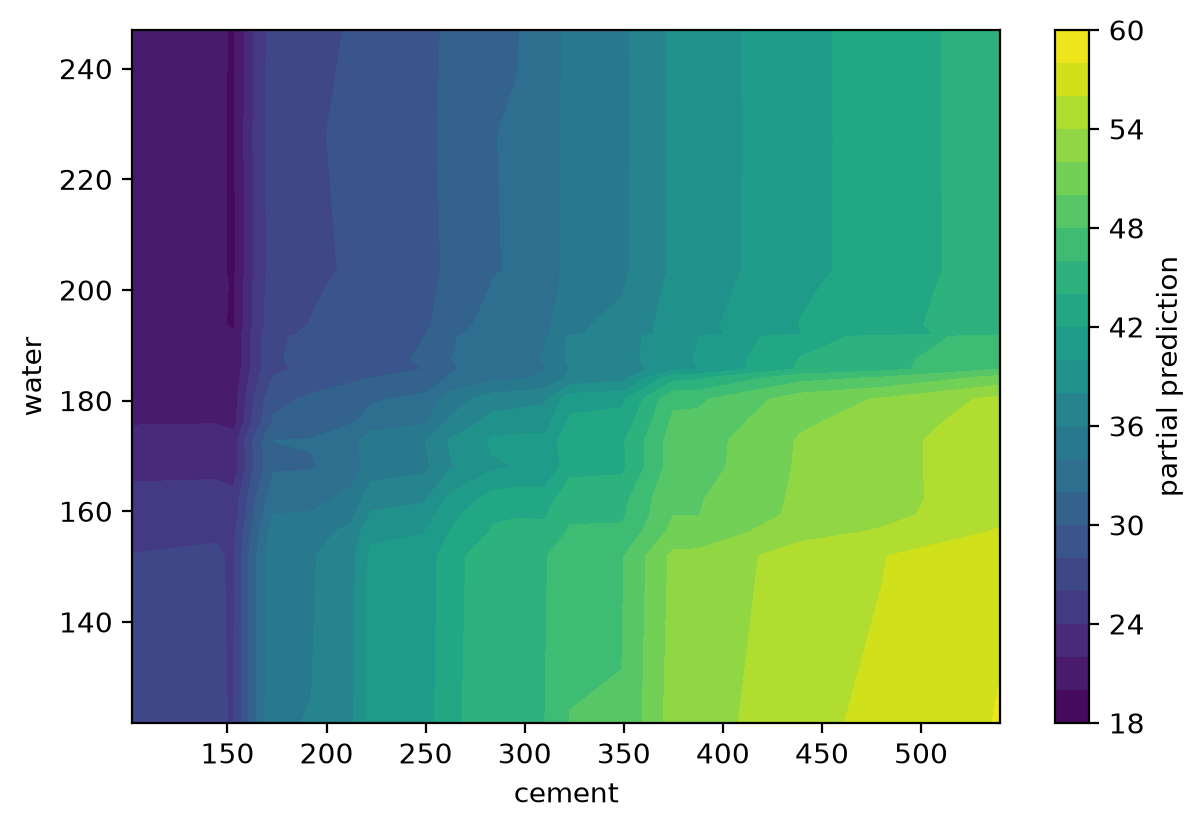

In [20]:
interaction = concrete.partial_dependence(Xc_train, ["cement", "water"])
interaction.plot();

Partial dependence repeatedly replaces the selected feature values and averages the resulting predictions. ICE retains the individual prediction lines. These plots describe the fitted model rather than a causal intervention, and highly correlated features can produce unrealistic synthetic rows.

Grouped features aggregate as one feature:

```python
enclosure = model.partial_dependence(X_train,
    {"enclosure": ["enclosure_ac", "enclosure_erops", "enclosure_orops"]})
```

### Collinearity and redundancy

In [21]:
relations = feature_relations(Xc_train)
relations.groups(threshold=0.2)

[('cement',),
 ('blast_furnace_slag',),
 ('fly_ash',),
 ('water',),
 ('superplasticizer',),
 ('coarse_aggregate',),
 ('fine_aggregate',),
 ('age',)]

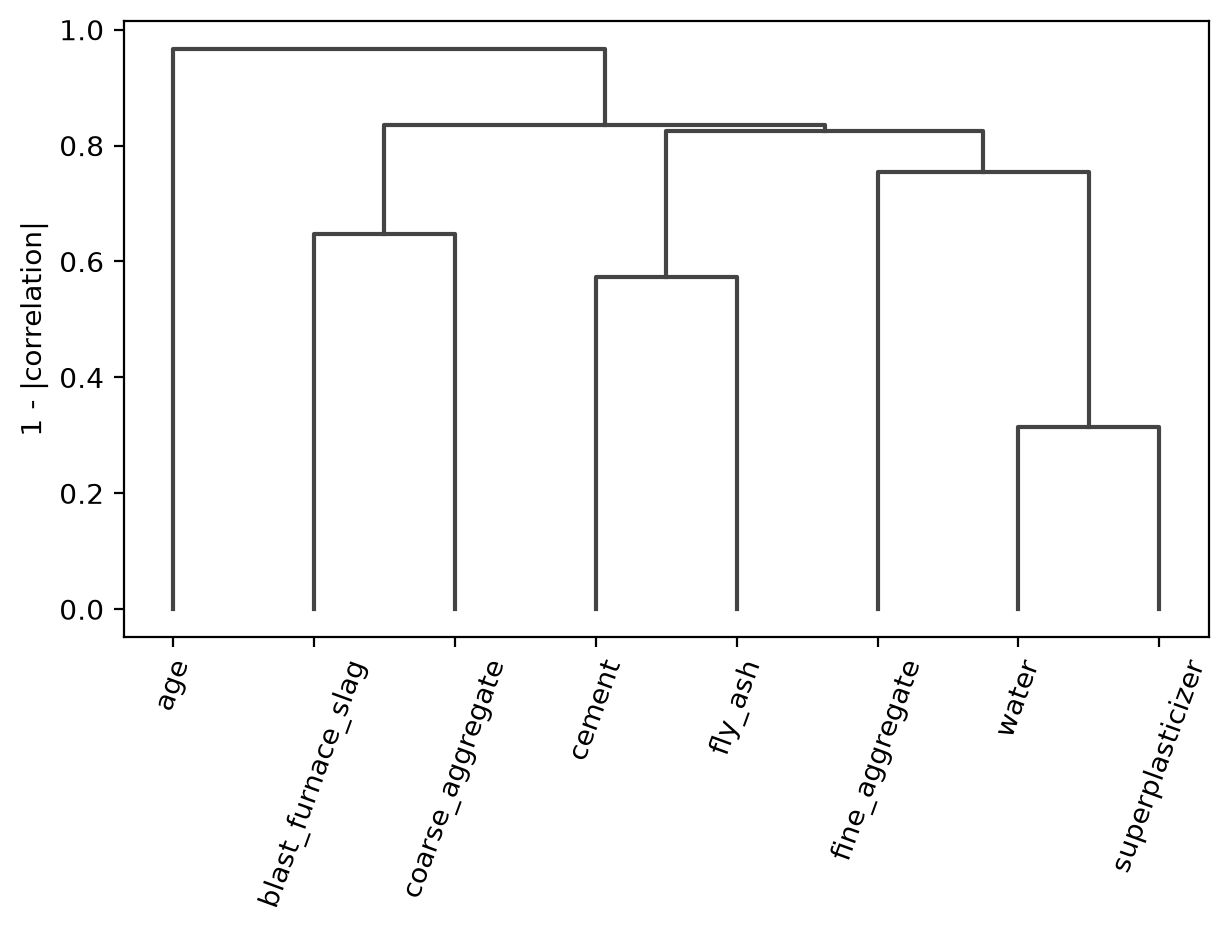

In [22]:
relations.plot_dendrogram();

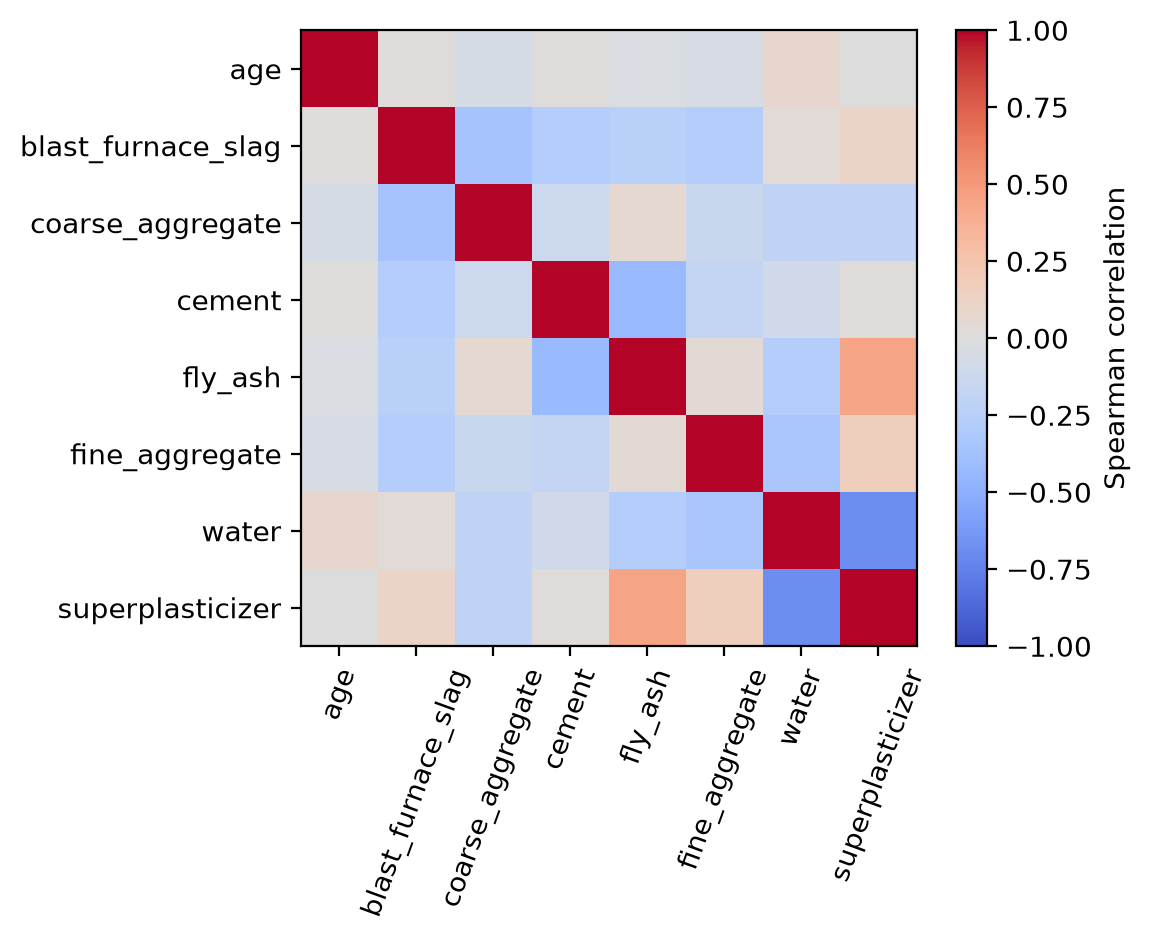

In [23]:
relations.plot();

`feature_dependence` complements correlation: it measures how predictable each feature is from the others, in any nonlinear form the forest can capture.

In [24]:
dependence = feature_dependence(Xc_train)
dependence.predictability

array([ 0.92725313,  0.86571008,  0.93969655,  0.89854634,  0.93675119,
        0.9088245 ,  0.93071157, -0.02972996])

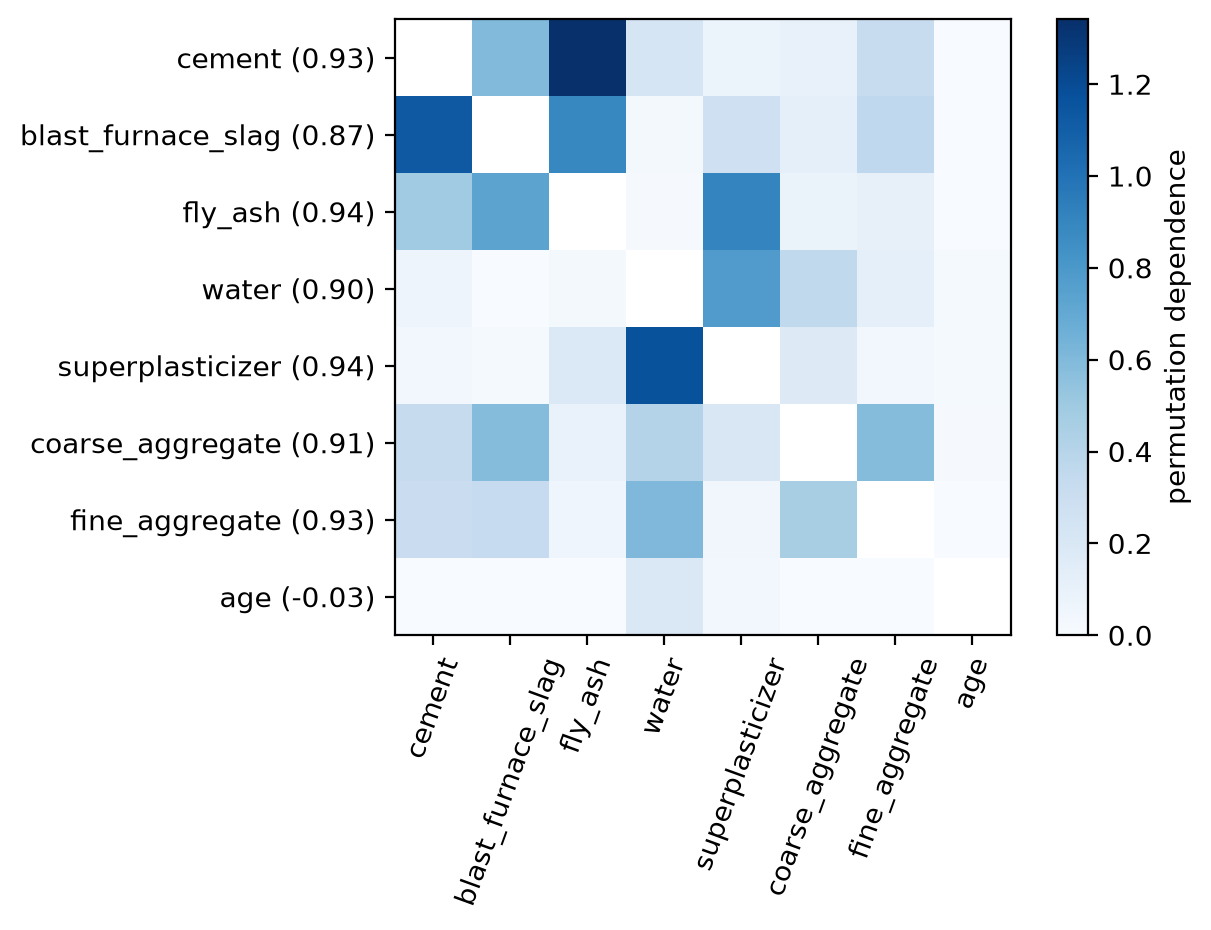

In [25]:
dependence.plot();

`feature_relations` uses tie-aware Spearman correlation and average linkage implemented directly with NumPy. `feature_dependence` detects nonlinear redundancy by treating each feature in turn as a target, fitting a small forest from the remaining features, and measuring grouped prediction and permutation dependence.

## Development

The project is locally installed with maturin until it joins the aai-ws workspace:

```bash
cargo build --release --bins
python tools/stage_binaries.py
maturin develop
cargo test
pytest -q
```

For performance work, build the extension in release mode and run the benchmark:

```bash
maturin develop --release
python tools/bench.py
```

Compare accuracy and timings against sklearn's random forest and histogram GBM on one fixed California Housing split:

```bash
python tools/accuracy.py
```

`README.md` is generated from `nbs/index.ipynb`. The displayed results live in `tools/results/`. After updating those CSVs, re-execute the notebook and run `nbdev-readme`.

Use `--dataset concrete` for the smaller Concrete Compressive Strength regression dataset, or `--dataset sgemm` for the 241,600-row SGEMM GPU Kernel Performance dataset. Each model/dataset combination runs in an isolated process with a three-minute timeout; process startup and input transfer are excluded from reported timings.

Use `--ff_only` with `--min_node_size`, `--bootstrap_fraction`, `--bootstrap_max`, `--replacement`, `--max_node_samples`, and `--cutoff_divisor` for focused FastForest experiments. These spellings come directly from the `call_parse` function parameters.